/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/2089967274.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.stripplot(x='Group', y='NP factor', data=df, jitter=0.2, palette=custom_palette, size=6, alpha=0.6)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/2089967274.py:16: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x='Group', y='NP factor', data=df, join=False, estimator=np.mean, errorbar='sd', color='black',markers='.',scale=1, zorder=1)
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/2089967274.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the li

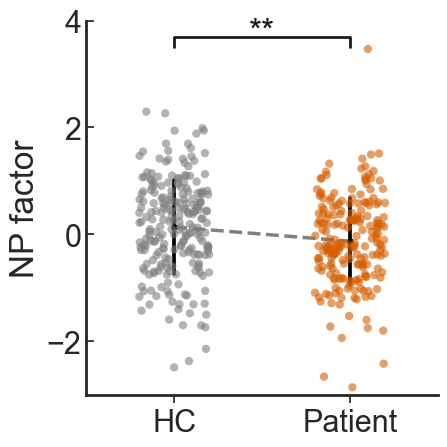

In [75]:
# ------- 图2：Neg_NP -------
# 读取数据
#df = pd.read_csv('D:\postdoc\Work\Computer-Brain-Project\Figures\Figure2\pos_neg_np_stratify_resi.csv')  # ← 改成你上传的文件名，例如 'data.csv'

# 设置绘图样式
sns.set_context("talk")
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
custom_palette = {
    'HC': '#7F7F7F',            
    'Patient': '#D55E00'        
}
# 准备组对比
pairs = [('HC', 'Patient')]

ax = sns.stripplot(x='Group', y='NP factor', data=df, jitter=0.2, palette=custom_palette, size=6, alpha=0.6)
sns.pointplot(x='Group', y='NP factor', data=df, join=False, estimator=np.mean, errorbar='sd', color='black',markers='.',scale=1, zorder=1)
# 添加均值之间的连线
mean_hc = df[df['Group'] == 'HC']['NP factor'].mean()
mean_pt = df[df['Group'] == 'Patient']['NP factor'].mean()
plt.plot([0, 1], [mean_hc, mean_pt], color='gray', linewidth=2.5, linestyle='--', zorder=0)


ax.tick_params(axis='y', direction='in')
ax.set_ylim(-3, 4)
sns.despine()

#plt.hlines(y=5, xmin=0, xmax=1, colors='k')
#ax.text(0.5, 6, "***", ha='center', va='bottom', color='k', fontsize=30)
# 手动添加显著性线和星号
# 比如你想在组1和组2之间画线
x1, x2 = 0, 1      # 两组在x轴上的位置（对应 Group2=1 和 Group2=2）
y = 3.5              # 横线的位置（y坐标）
h = 0.2            # 横线和星号之间的高度间隔
# 画横线
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
# 添加显著性标注（例如星号）
ax.text((x1+x2)*.5, y+h-0.2, "**", ha='center', va='bottom', color='k', fontsize=24)

#annotator = Annotator(ax, pairs, data=df, x='Group', y='NP factor')
#annotator.configure(test='t-test_ind', text_format='star', loc='inside') 
#annotator.apply_and_annotate()
plt.xlim(-0.5, 1.5)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.xlabel("")
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/compare_NP_factor.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

# 1. 基础全局设置
palette = {'Placebo': '#7F7F7F', 'Ketamine': '#E1D09A', 'Midazolam': '#96B9AD'}
sns.set(font_scale=2, style="ticks")

def draw_single_paired_plot(df, group_name, cond1, cond2, save_name):
    """
    输入参数：数据框, 分组名, 条件1, 条件2, 保存文件名
    """
    # 数据过滤
    df_pair = df[(df['Kmeans_group'] == group_name) & (df['Condition'].isin([cond1, cond2]))].copy()
    df_pair['Condition'] = pd.Categorical(df_pair['Condition'], categories=[cond1, cond2], ordered=True)

    # 创建画布 (固定为单个子图尺寸)
    fig, ax = plt.subplots(figsize=(5, 5))

    # --- 第一层：半透明 Boxplot (背景) ---
    sns.boxplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        width=0.4, palette=palette, fliersize=0, linewidth=2.5,
        boxprops=dict(alpha=0.8, edgecolor='black'), # alpha控制透明度
        zorder=1
    )

    # --- 第二层：Paired Lines (中间层) ---
    for subj in df_pair['Subject'].unique():
        subj_data = df_pair[df_pair['Subject'] == subj]
        if len(subj_data) == 2:
            y1 = subj_data.loc[subj_data['Condition'] == cond1, 'Score'].values[0]
            y2 = subj_data.loc[subj_data['Condition'] == cond2, 'Score'].values[0]
            ax.plot([0, 1], [y1, y2], color='gray', alpha=0.4, lw=2, zorder=2)

    # --- 第三层：Stripplot (最上层) ---
    sns.stripplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        palette=palette, jitter=False, size=10, alpha=0.9, 
        linewidth=1, edgecolor='white', zorder=3
    )

    # 显著性标注 (配对 T 检验)
    annotator = Annotator(ax, [(cond1, cond2)], data=df_pair, x='Condition', y='Score', order=[cond1, cond2])
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', fontsize=24, line_width=2.5)
    annotator.apply_and_annotate()

    # 细节修饰
    ax.set_ylim(-1.5, 2) # 统一两个子图的量程，方便对比
    ax.set_ylabel('Summed MID FCs', fontsize=24)
    ax.set_xlabel('')
    for spine in ax.spines.values(): spine.set_linewidth(2.5) # 加粗边框
    
    ax.tick_params(axis='both', which='major', width=2.5, length=6, labelsize=20)
    ax.tick_params(axis='y', direction='in')
    sns.despine()
    
    plt.tight_layout()
    plt.savefig(f'/Users/yunman/Desktop/submission/figures/fig4/{save_name}.png', dpi=300)
    plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

# 1. 配色方案设置
# 散点配色（代表药物条件）
drug_palette = {'Placebo': '#7F7F7F', 'Ketamine': '#E1D09A', 'Midazolam': '#96B9AD'}

# Box配色（代表分组趋势：比如 Group1-上升用红色系，Group2-下降用蓝色系）
# 这里使用半透明感或淡色，以免抢了散点的风头
group_box_palette = {'Group1': '#ffffff', 'Group2': '#ffffff'}

def draw_complex_paired_plot(df, group_name, cond1, cond2, save_name):
    # 数据过滤
    df_pair = df[(df['Kmeans_group'] == group_name) & (df['Condition'].isin([cond1, cond2]))].copy()
    df_pair['Condition'] = pd.Categorical(df_pair['Condition'], categories=[cond1, cond2], ordered=True)

    fig, ax = plt.subplots(figsize=(4, 4))

    # --- 第一层：区分 Group 的 Boxplot ---
    # 使用单一颜色填充，但通过 group_box_palette 赋予该组特定的色调
    sns.boxplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        width=0.4, 
        color=group_box_palette[group_name], # 👈 这里根据传入的 group_name 变色
        fliersize=0, linewidth=2.5,
        boxprops=dict(alpha=0.4, edgecolor='black'), # 透明度设为 0.4
        zorder=1
    )

    # --- 第二层：Paired Lines (个体内连线) ---
    for subj in df_pair['Subject'].unique():
        subj_data = df_pair[df_pair['Subject'] == subj]
        if len(subj_data) == 2:
            y1 = subj_data.loc[subj_data['Condition'] == cond1, 'Score'].values[0]
            y2 = subj_data.loc[subj_data['Condition'] == cond2, 'Score'].values[0]
            ax.plot([0, 1], [y1, y2], color='gray', alpha=0.8, lw=2, zorder=2)

    # --- 第三层：保持药物颜色的 Stripplot ---
    sns.stripplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        palette=drug_palette, # 👈 散点依然按药物着色
        jitter=False, size=10, alpha=1, 
        linewidth=1.5, edgecolor='black', zorder=3
    )

    # 显著性标注
    annotator = Annotator(ax, [(cond1, cond2)], data=df_pair, x='Condition', y='Score', order=[cond1, cond2])
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', fontsize=24, line_width=2.5)
    annotator.apply_and_annotate()

    # 细节微调
    ax.set_ylim(-1.5, 2)
    ax.set_ylabel('Summed MID FCs', fontsize=24)
    ax.set_xlabel('')
    for spine in ax.spines.values(): spine.set_linewidth(2.5)

    ax.tick_params(axis='both', which='major', width=2.5, length=6, labelsize=20)
    ax.tick_params(axis='y', direction='in')
    sns.despine()
    
    plt.tight_layout()
    plt.savefig(f'/Users/yunman/Desktop/submission/figures/fig4/{save_name}.png', dpi=300)
    plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Midazolam: t-test paired samples, P_val:4.274e-03 t=4.154e+00


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_50773/2798650561.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


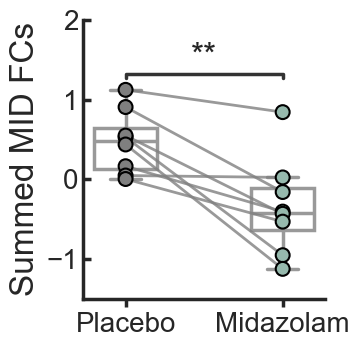

In [7]:
draw_complex_paired_plot(df, 'Group1', 'Placebo', 'Midazolam', 'fig4_Midazolam_paired')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Ketamine: t-test paired samples, P_val:5.740e-03 t=3.921e+00


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_50773/2798650561.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


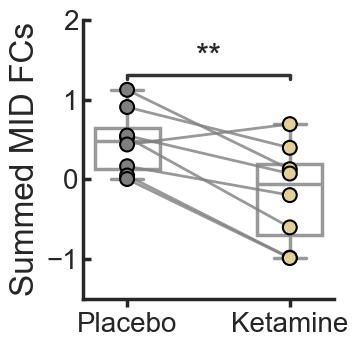

In [8]:
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/pharmacological_exper/summed_MID_FCs_3conditions.csv')
draw_complex_paired_plot(df, 'Group1', 'Placebo', 'Ketamine', 'fig4_Ketamine_paired')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Ketamine: t-test paired samples, P_val:1.820e-02 t=-2.597e+00


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_50773/2798650561.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


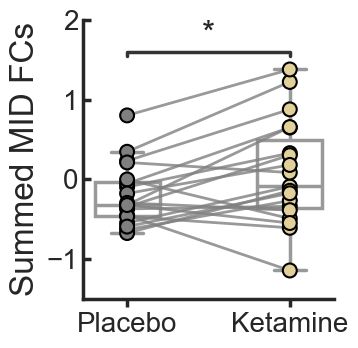

In [6]:
draw_complex_paired_plot(df, 'Group2', 'Placebo', 'Ketamine', 'fig4_Ketamine_group2')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Midazolam: t-test paired samples, P_val:1.878e-02 t=-2.582e+00


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/2798650561.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


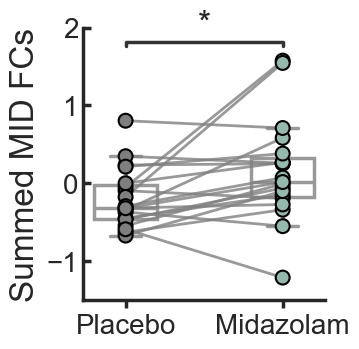

In [53]:
draw_complex_paired_plot(df, 'Group2', 'Placebo', 'Midazolam', 'fig4_midazolam_group2')

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

# 1. 配色方案设置
# 散点配色（代表药物条件）
drug_palette = {'Placebo': '#7F7F7F', 'Ketamine': '#E1D09A', 'Midazolam': '#96B9AD'}

# Box配色（代表分组趋势：比如 Group1-上升用红色系，Group2-下降用蓝色系）
# 这里使用半透明感或淡色，以免抢了散点的风头
group_box_palette = {'Group1': '#ffffff', 'Group2': '#ffffff'}

def draw_complex_paired_plot(df, group_name, cond1, cond2, save_name):
    # 数据过滤
    df_pair = df[(df['Kmeans_group'] == group_name) & (df['Condition'].isin([cond1, cond2]))].copy()
    df_pair['Condition'] = pd.Categorical(df_pair['Condition'], categories=[cond1, cond2], ordered=True)

    fig, ax = plt.subplots(figsize=(4, 4))

    # --- 第一层：区分 Group 的 Boxplot ---
    # 使用单一颜色填充，但通过 group_box_palette 赋予该组特定的色调
    sns.boxplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        width=0.4, 
        color=group_box_palette[group_name], # 👈 这里根据传入的 group_name 变色
        fliersize=0, linewidth=2.5,
        boxprops=dict(alpha=0.4, edgecolor='black'), # 透明度设为 0.4
        zorder=1
    )

    # --- 第二层：Paired Lines (个体内连线) ---
    for subj in df_pair['Subject'].unique():
        subj_data = df_pair[df_pair['Subject'] == subj]
        if len(subj_data) == 2:
            y1 = subj_data.loc[subj_data['Condition'] == cond1, 'Score'].values[0]
            y2 = subj_data.loc[subj_data['Condition'] == cond2, 'Score'].values[0]
            ax.plot([0, 1], [y1, y2], color='gray', alpha=0.8, lw=2, zorder=2)

    # --- 第三层：保持药物颜色的 Stripplot ---
    sns.stripplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        palette=drug_palette, # 👈 散点依然按药物着色
        jitter=False, size=10, alpha=1, 
        linewidth=1.5, edgecolor='black', zorder=3
    )

    # 显著性标注
    annotator = Annotator(ax, [(cond1, cond2)], data=df_pair, x='Condition', y='Score', order=[cond1, cond2])
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', fontsize=24, line_width=2.5)
    annotator.apply_and_annotate()

    # 细节微调
    ax.set_ylim(-4, 4)
    ax.set_ylabel('Summed MID FCs', fontsize=24)
    ax.set_xlabel('')
    for spine in ax.spines.values(): spine.set_linewidth(2.5)

    ax.tick_params(axis='both', which='major', width=2.5, length=6, labelsize=20)
    ax.tick_params(axis='y', direction='in')
    sns.despine()
    
    plt.tight_layout()
    plt.savefig(f'/Users/yunman/Desktop/submission/revision/New_pharma_dataset/{save_name}.png', dpi=300)
    plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Ketamine: t-test paired samples, P_val:9.196e-02 t=-1.766e+00


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_50773/188044858.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


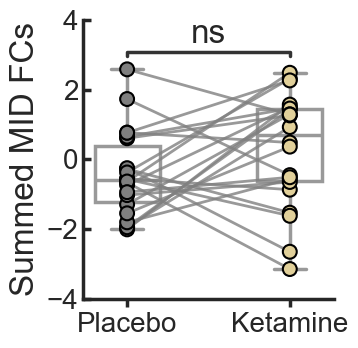

In [14]:
df = pd.read_csv('/Users/yunman/Desktop/submission/revision/New_pharma_dataset/summed_FCs_2conditions.csv')
draw_complex_paired_plot(df, 'Group2', 'Placebo', 'Ketamine', 'ketamine_change_mdd')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Ketamine: t-test paired samples, P_val:8.280e-02 t=1.879e+00


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_50773/188044858.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


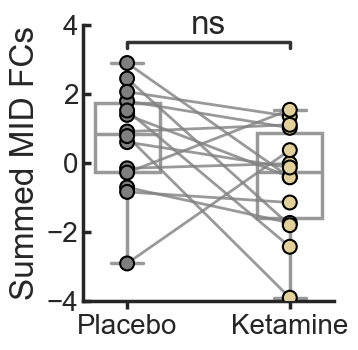

In [15]:
draw_complex_paired_plot(df, 'Group1', 'Placebo', 'Ketamine', 'ketamine_change_hc')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Ketamine: n.s.


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/191244946.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/opt/miniconda3/envs/pydata/lib/python3.11/site-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


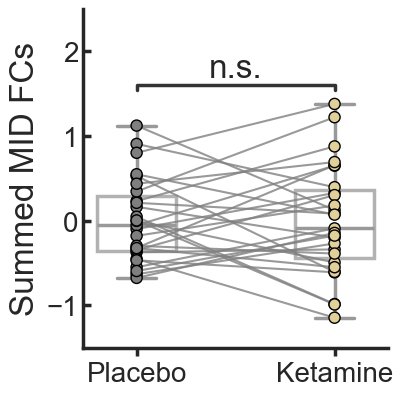

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/191244946.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Placebo vs. Midazolam: n.s.


/opt/miniconda3/envs/pydata/lib/python3.11/site-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


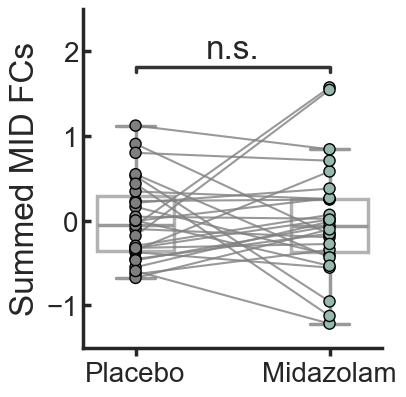

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

# 1. 配色方案设置 (保持一致)
drug_palette = {'Placebo': '#7F7F7F', 'Ketamine': '#E1D09A', 'Midazolam': '#96B9AD'}
# 统一的 Box 颜色（例如使用淡灰色或特定主题色）
box_color = '#ffffff' 

def draw_drug_paired_plot(df, cond1, cond2, save_name):
    # 过滤数据：选择指定的两个药物条件
    df_pair = df[df['Condition'].isin([cond1, cond2])].copy()
    df_pair['Condition'] = pd.Categorical(df_pair['Condition'], categories=[cond1, cond2], ordered=True)

    fig, ax = plt.subplots(figsize=(4.5, 4.5))

    # --- 第一层：Boxplot (展示总体分布) ---
    sns.boxplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        width=0.4, 
        color=box_color, 
        fliersize=0, linewidth=2.5,
        boxprops=dict(alpha=0.3, edgecolor='black'), # 降低透明度突出散点
        zorder=1
    )

    # --- 第二层：Paired Lines (个体内连线) ---
    # 确保只连接在这两个条件下都有数据的受试者
    common_subjects = df_pair.groupby('Subject').filter(lambda x: len(x) == 2)['Subject'].unique()
    for subj in common_subjects:
        subj_data = df_pair[df_pair['Subject'] == subj]
        y1 = subj_data.loc[subj_data['Condition'] == cond1, 'Score'].values[0]
        y2 = subj_data.loc[subj_data['Condition'] == cond2, 'Score'].values[0]
        ax.plot([0, 1], [y1, y2], color='gray', alpha=0.8, lw=1.5, zorder=2)

    # --- 第三层：Stripplot (按药物颜色着色) ---
    sns.stripplot(
        x='Condition', y='Score', data=df_pair, ax=ax,
        palette=drug_palette,
        jitter=False, size=8, alpha=1, 
        linewidth=1, edgecolor='black', zorder=3
    )
    # 计算 P 值
    from scipy.stats import ttest_rel
    v1 = df_pair[df_pair['Condition'] == cond1]['Score']
    v2 = df_pair[df_pair['Condition'] == cond2]['Score']
    _, p_val = ttest_rel(v1, v2)

    # 根据 P 值确定标注
    if p_val < 0.001: sig_str = "***"
    elif p_val < 0.01: sig_str = "**"
    elif p_val < 0.05: sig_str = "*"
    else: sig_str = "n.s."

   # 使用自定义标注
    annotator = Annotator(ax, [(cond1, cond2)], data=df_pair, x='Condition', y='Score', order=[cond1, cond2])
    annotator.set_custom_annotations([sig_str]) # 👈 强制使用 "n.s."
    annotator.configure(test='t-test_paired', loc='inside', fontsize=24, line_width=2.5)
    annotator.annotate()

    # --- 显著性标注 (配对 T 检验) ---
    #annotator = Annotator(ax, [(cond1, cond2)], data=df_pair, x='Condition', y='Score', order=[cond1, cond2])
    #annotator.configure(test='t-test_paired', text_format='star', loc='inside', fontsize=24, line_width=2.5)
    #annotator.set_custom_annotations(["n.s." if p > 0.05 else "*" for p in [your_p_value]])
    #annotator.apply_and_annotate()

    # 细节美化
    ax.set_ylabel('Summed MID FCs', fontsize=24)
    ax.set_xlabel('')
    ax.set_ylim(-1.5, 2.5) # 根据数据范围调整
    for spine in ax.spines.values(): spine.set_linewidth(2.5)
    ax.tick_params(axis='both', which='major', width=2.5, length=6, labelsize=20)
    ax.tick_params(axis='y', direction='in')
    sns.despine()
    
    plt.tight_layout()
    plt.savefig(f'/Users/yunman/Desktop/submission/figures/fig4/{save_name}.png', dpi=300)
    plt.show()

# 调用示例：
draw_drug_paired_plot(df, 'Placebo', 'Ketamine', 'placebo_vs_ketamine')
draw_drug_paired_plot(df, 'Placebo', 'Midazolam', 'placebo_vs_midazolam')

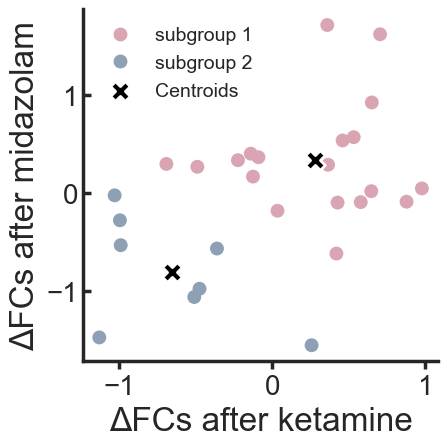

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 模拟你的数据结构 (如果你已经有 df，请跳过此步)
# df = pd.read_csv('your_data.csv')
df=pd.read_csv('/Users/yunman/Desktop/submission/final_file/kmeans_results.csv')
# 2. 设置配色
# 对于两个类别，建议使用你之前用过的对比色
cluster_palette = {1: '#D9A5B3', 2: '#8DA0B4'} 

plt.figure(figsize=(5, 5))
ax = plt.gca()

# 3. 计算每个簇的质心 (Centroids)
# 这一步能直观展示 K-means 的核心逻辑
centroids = df.groupby('idx')[['x', 'y']].mean()

# 4. 绘制散点图
sns.scatterplot(
    data=df, x='x', y='y', hue='idx', 
    palette=cluster_palette, s=100, alpha=1, 
    edgecolor='none', linewidth=0.8, ax=ax
)

# 5. 绘制质心 (用醒目的星号或交叉表示)
ax.scatter(
    centroids['x'], centroids['y'], 
    marker='X', s=200, c='black', label='Centroids',
    edgecolor='white', linewidth=2, zorder=10
)

# 6. 可选：绘制简单的连接线或包围圈（让分类感更强）
# 这里我们简单美化坐标轴
ax.set_xlabel('ΔFCs after ketamine', fontsize=24)
ax.set_ylabel('ΔFCs after midazolam', fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=20, width=2.5, length=6)
ax.tick_params(axis='y', direction='in')

# 移除上、右边框
sns.despine()
for spine in ax.spines.values(): spine.set_linewidth(2.5)

# 自定义图例
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ['subgroup 1', 'subgroup 2', 'Centroids'], 
           frameon=False, fontsize=14, loc='best')
plt.tight_layout()
plt.savefig(f'/Users/yunman/Desktop/submission/figures/fig4/kmeans.png', dpi=300)
plt.show()

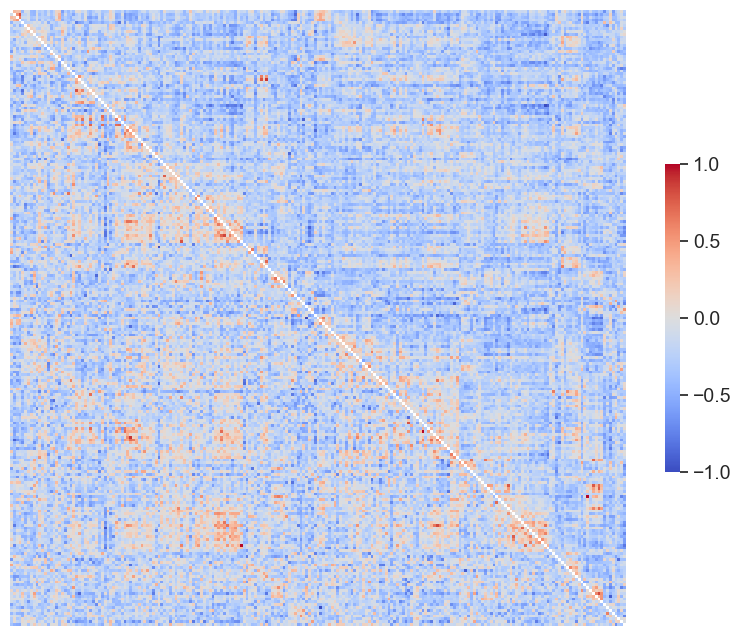

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取两个矩阵（示例）
real_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_real_mid_antici_hit.csv', header=None).values
sim_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_mid_antici_hit.csv', header=None).values

min_real_data = np.min(real_data)
max_real_data = np.max(real_data)

min_sim_data = np.min(sim_data)
max_sim_data = np.max(sim_data)
# 线性归一化到 [-1, 1]
real_data_norm = 2 * (real_data - min_real_data) / (max_real_data - min_real_data ) - 1
sim_data_norm = 2 * (sim_data - min_sim_data) / (max_sim_data - min_sim_data) - 1

# 确保两个矩阵大小相同
assert real_data_norm.shape == sim_data_norm.shape

n = real_data_norm.shape[0]

# 创建一个空矩阵，准备拼接
combined = np.zeros((n, n))

# 上三角(不包含对角线)用模拟数据的上三角
triu_indices = np.triu_indices(n, k=1)
combined[triu_indices] = sim_data_norm[triu_indices]

# 下三角(不包含对角线)用真实数据的下三角
tril_indices = np.tril_indices(n, k=-1)
combined[tril_indices] = real_data_norm[tril_indices]

# 对角线一般设为0或者NaN，不画色
np.fill_diagonal(combined, 0)

# 画图
sns.set_theme(style="white")
mask = np.zeros_like(combined, dtype=bool)
mask[np.diag_indices_from(mask)] = True  # 对角线遮罩

plt.figure(figsize=(10, 8))
g = sns.heatmap(combined, mask=mask, cmap="coolwarm", center=0, square=True,
                linewidths=0, cbar_kws={"shrink": .5}, vmax=1, vmin=-1)
# 调节colorbar字体大小和字体
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
for t in cbar.ax.get_yticklabels():
    t.set_fontname('Arial')
# 加标题和标签
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])

plt.savefig('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/sim_vs_real_mid_antici_hit.png',
            dpi=300, bbox_inches='tight', transparent=True)

plt.show()


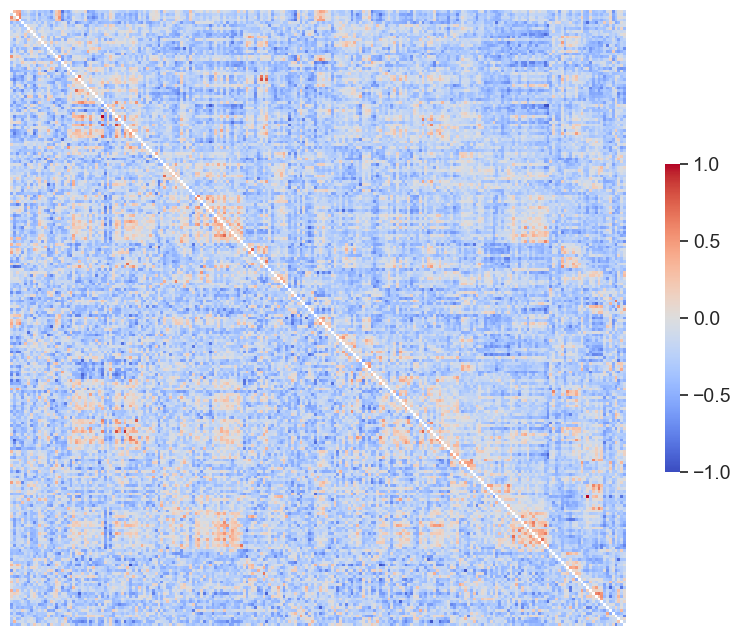

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取两个矩阵（示例）
real_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_real_mid_feed_hit.csv', header=None).values
sim_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_mid_feed_hit.csv', header=None).values

min_real_data = np.min(real_data)
max_real_data = np.max(real_data)

min_sim_data = np.min(sim_data)
max_sim_data = np.max(sim_data)
# 线性归一化到 [-1, 1]
real_data_norm = 2 * (real_data - min_real_data) / (max_real_data - min_real_data ) - 1
sim_data_norm = 2 * (sim_data - min_sim_data) / (max_sim_data - min_sim_data) - 1

# 确保两个矩阵大小相同
assert real_data_norm.shape == sim_data_norm.shape

n = real_data_norm.shape[0]

# 创建一个空矩阵，准备拼接
combined = np.zeros((n, n))

# 上三角(不包含对角线)用模拟数据的上三角
triu_indices = np.triu_indices(n, k=1)
combined[triu_indices] = sim_data_norm[triu_indices]

# 下三角(不包含对角线)用真实数据的下三角
tril_indices = np.tril_indices(n, k=-1)
combined[tril_indices] = real_data_norm[tril_indices]

# 对角线一般设为0或者NaN，不画色
np.fill_diagonal(combined, 0)

# 画图
sns.set_theme(style="white")
mask = np.zeros_like(combined, dtype=bool)
mask[np.diag_indices_from(mask)] = True  # 对角线遮罩

plt.figure(figsize=(10, 8))
g = sns.heatmap(combined, mask=mask, cmap="coolwarm", center=0, square=True,
                linewidths=0, cbar_kws={"shrink": .5}, vmax=1, vmin=-1)
# 调节colorbar字体大小和字体
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
for t in cbar.ax.get_yticklabels():
    t.set_fontname('Arial')
# 加标题和标签
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])

plt.savefig('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/sim_vs_real_mid_feed_hit.png',
            dpi=300, bbox_inches='tight', transparent=True)

plt.show()


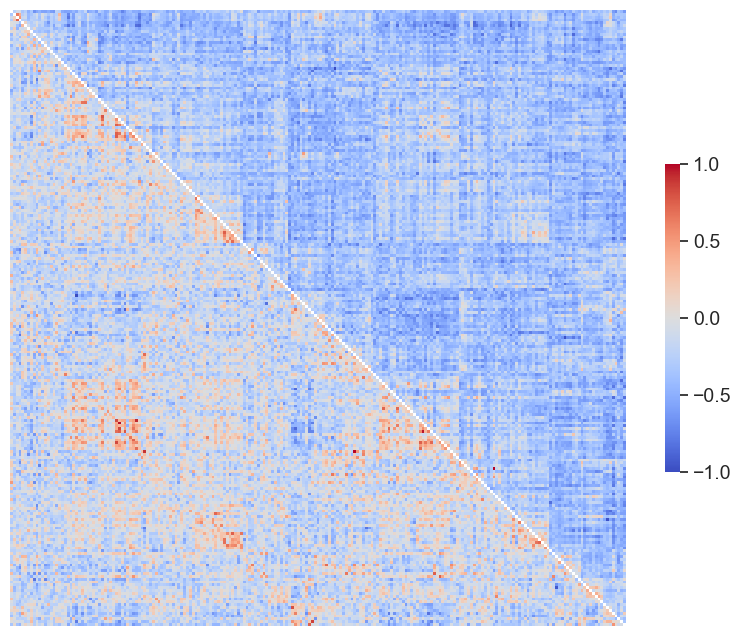

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取两个矩阵（示例）
real_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_real_sst_stop_failure.csv', header=None).values
sim_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_sst_stop_failure.csv', header=None).values

min_real_data = np.min(real_data)
max_real_data = np.max(real_data)

min_sim_data = np.min(sim_data)
max_sim_data = np.max(sim_data)
# 线性归一化到 [-1, 1]
real_data_norm = 2 * (real_data - min_real_data) / (max_real_data - min_real_data ) - 1
sim_data_norm = 2 * (sim_data - min_sim_data) / (max_sim_data - min_sim_data) - 1

# 确保两个矩阵大小相同
assert real_data_norm.shape == sim_data_norm.shape

n = real_data_norm.shape[0]

# 创建一个空矩阵，准备拼接
combined = np.zeros((n, n))

# 上三角(不包含对角线)用模拟数据的上三角
triu_indices = np.triu_indices(n, k=1)
combined[triu_indices] = sim_data_norm[triu_indices]

# 下三角(不包含对角线)用真实数据的下三角
tril_indices = np.tril_indices(n, k=-1)
combined[tril_indices] = real_data_norm[tril_indices]

# 对角线一般设为0或者NaN，不画色
np.fill_diagonal(combined, 0)

# 画图
sns.set_theme(style="white")
mask = np.zeros_like(combined, dtype=bool)
mask[np.diag_indices_from(mask)] = True  # 对角线遮罩

plt.figure(figsize=(10, 8))
g = sns.heatmap(combined, mask=mask, cmap="coolwarm", center=0, square=True,
                linewidths=0, cbar_kws={"shrink": .5}, vmax=1, vmin=-1)
# 调节colorbar字体大小和字体
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
for t in cbar.ax.get_yticklabels():
    t.set_fontname('Arial')
# 加标题和标签
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])

plt.savefig('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/sim_vs_real_sst_stop_failure.png',
            dpi=300, bbox_inches='tight', transparent=True)

plt.show()


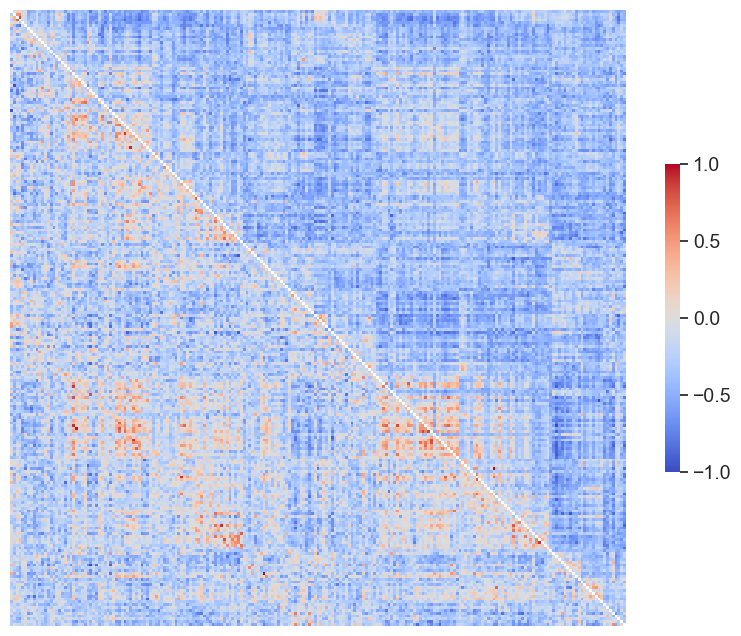

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取两个矩阵（示例）
real_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_real_sst_stop_suces.csv', header=None).values
sim_data = pd.read_csv('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/hc01_sst_stop_suces.csv', header=None).values

min_real_data = np.min(real_data)
max_real_data = np.max(real_data)

min_sim_data = np.min(sim_data)
max_sim_data = np.max(sim_data)
# 线性归一化到 [-1, 1]
real_data_norm = 2 * (real_data - min_real_data) / (max_real_data - min_real_data ) - 1
sim_data_norm = 2 * (sim_data - min_sim_data) / (max_sim_data - min_sim_data) - 1

# 确保两个矩阵大小相同
assert real_data_norm.shape == sim_data_norm.shape

n = real_data_norm.shape[0]

# 创建一个空矩阵，准备拼接
combined = np.zeros((n, n))

# 上三角(不包含对角线)用模拟数据的上三角
triu_indices = np.triu_indices(n, k=1)
combined[triu_indices] = sim_data_norm[triu_indices]

# 下三角(不包含对角线)用真实数据的下三角
tril_indices = np.tril_indices(n, k=-1)
combined[tril_indices] = real_data_norm[tril_indices]

# 对角线一般设为0或者NaN，不画色
np.fill_diagonal(combined, 0)

# 画图
sns.set_theme(style="white")
mask = np.zeros_like(combined, dtype=bool)
mask[np.diag_indices_from(mask)] = True  # 对角线遮罩

plt.figure(figsize=(10, 8))
g = sns.heatmap(combined, mask=mask, cmap="coolwarm", center=0, square=True,
                linewidths=0, cbar_kws={"shrink": .5}, vmax=1, vmin=-1)
# 调节colorbar字体大小和字体
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
for t in cbar.ax.get_yticklabels():
    t.set_fontname('Arial')
# 加标题和标签
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])

plt.savefig('D:/postdoc/Work/Computer-Brain-Project/Figures/Figure3/sim_vs_real_sst_stop_suces.png',
            dpi=300, bbox_inches='tight', transparent=True)

plt.show()


In [ ]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
!pip install statannotations

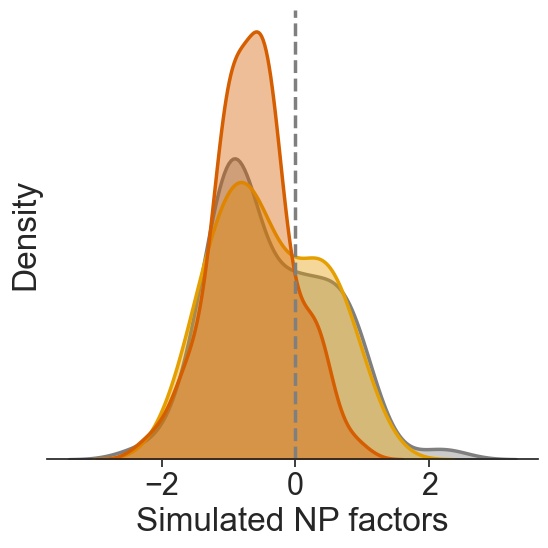

In [367]:
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig3/group_empir_simu_manipu_np_Resi3.csv')
plt.figure(figsize=(6,6))

# 1️⃣ 自定义每个组的颜色
group_colors = {
    'HC': '#7F7F7F',
    'High-symptom':'#E69F00',
    'Patient':'#D55E00'
}

groups = df['Group'].unique()
group_order = ['HC','High-symptom','Patient']
for g in group_order:
    subset = df[(df.Group == g) & (df.source == 'simulated')]
    
    sns.kdeplot(
        subset['NP'],
        fill=True,
        alpha=0.4,
        linewidth=2.5,
        color=group_colors[g],   # 👈 使用自定义颜色
        label=g
    )
# 画竖线标记 x=0
plt.axvline(x=0, color='#7F7F7F', linestyle='--', linewidth=2.5)
plt.xlabel("Simulated NP factors")
plt.yticks([])
sns.despine(left=True)
#plt.legend(title="Group")
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/simulate_np_3groups.png', dpi=300, bbox_inches='tight')
plt.show()

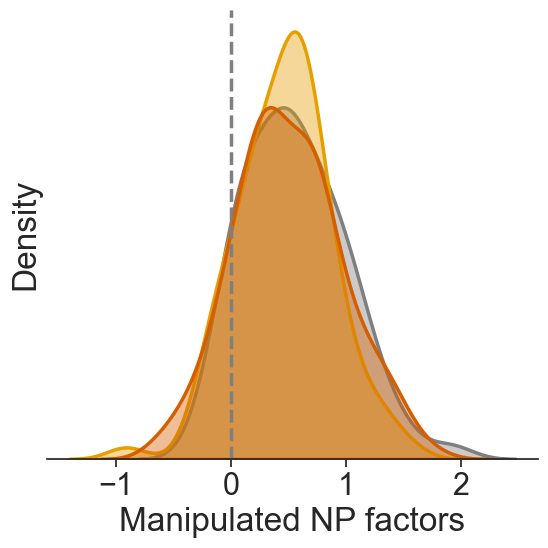

In [368]:
plt.figure(figsize=(6,6))
group_colors = {
    'HC': '#7F7F7F',
    'High-symptom':'#E69F00',
    'Patient':'#D55E00'
}

groups = df['Group'].unique()
group_order = ['HC','High-symptom','Patient']

for g in group_order:
    subset = df[(df.Group == g) & (df.source == 'manipu_ampa')]
    
    sns.kdeplot(
        subset['NP'],
        fill=True,
        alpha=0.4,
        linewidth=2.5,
        color=group_colors[g],   # 👈 使用自定义颜色
        label=g
    )
plt.axvline(x=0, color='#7F7F7F', linestyle='--', linewidth=2.5)
plt.xlabel("Manipulated NP factors")
plt.yticks([])
sns.despine(left=True)
#plt.legend(title="Group")
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/manipu_ampa_np_3groups.png', dpi=300, bbox_inches='tight')
plt.show()

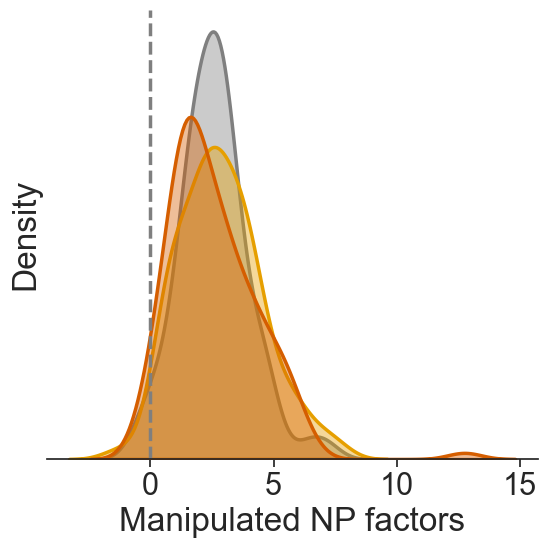

In [369]:
plt.figure(figsize=(6,6))
group_colors = {
    'HC': '#7F7F7F',
    'High-symptom':'#E69F00',
    'Patient':'#D55E00'
}

groups = df['Group'].unique()
group_order = ['HC','High-symptom','Patient']

for g in group_order:
    subset = df[(df.Group == g) & (df.source == 'manipu_gaba-a')]
    
    sns.kdeplot(
        subset['NP'],
        fill=True,
        alpha=0.4,
        linewidth=2.5,
        color=group_colors[g],   # 👈 使用自定义颜色
        label=g
    )
plt.axvline(x=0, color='#7F7F7F', linestyle='--', linewidth=2.5)
plt.xlabel("Manipulated NP factors")
plt.yticks([])
sns.despine(left=True)
#plt.legend(title="Group")
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/manipu_gaba_np_3groups.png', dpi=300, bbox_inches='tight')
plt.show()

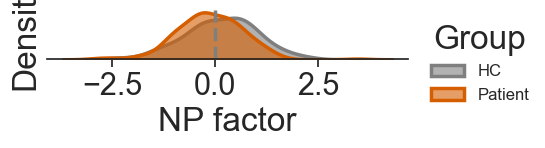

In [86]:
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig1/empir_pos_neg_np_stratify_without_ed.csv')
plt.figure(figsize=(6,2))

# 1️⃣ 自定义每个组的颜色
group_colors = {
    'HC': '#7F7F7F',
    'Patient':'#D55E00'
}

groups = df['Group'].unique()
group_order = ['HC','Patient']
for g in group_order:
    subset = df[(df.Group == g) & (df.source == 'NP_factor')]
    
    sns.kdeplot(
        subset['NP'],
        fill=True,
        alpha=0.6,
        linewidth=2.5,
        color=group_colors[g],   # 👈 使用自定义颜色
        label=g
    )
# 画竖线标记 x=0
plt.axvline(x=0, color='#7F7F7F', linestyle='--', linewidth=2.5)
plt.xlabel("NP factor")
plt.yticks([])
sns.despine(left=True)
# 调整后的 Legend 设置：放在图外右侧，去掉边框增加高级感
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/compare_np_stratify_without_ed.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/4192473826.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Group', y='Neg_NP',


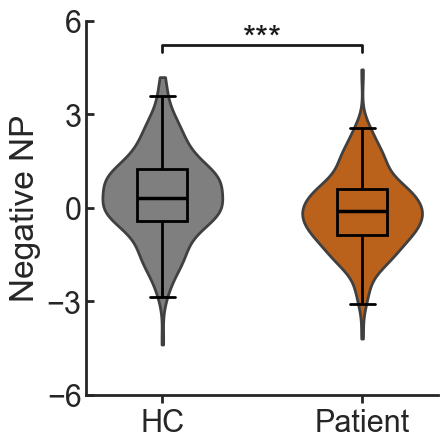

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig1/pos_neg_np_stratify_resi_without_ed.csv')

# 配色
palette = {
    'HC': (127/255, 127/255, 127/255),
    'Patient': (213/255, 94/255, 0/255)
}
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
sns.set_style("ticks")
# Violin plot + boxplot
ax = sns.violinplot(data=df, x='Group', y='Neg_NP',
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6,alpha=1)
sns.boxplot(
    data=df,
    x='Group',
    y='Neg_NP',
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')
# 添加显著性星号
group1 = df[df['Group'] == 'HC']['Neg_NP']
group2 = df[df['Group'] == 'Patient']['Neg_NP']

# 比如你想在组1和组2之间画线
x1, x2 = 0, 1      # 两组在x轴上的位置（对应 Group2=1 和 Group2=2）
y = 5              # 横线的位置（y坐标）
h = 0.2            # 横线和星号之间的高度间隔
# 画横线
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
# 添加显著性标注（例如星号）
ax.text((x1+x2)*.5, y+h-0.3, "***", ha='center', va='bottom', color='k', fontsize=24)

ax.set_ylim(-6, 6)
ax.set_yticks([-6,-3,0,3,6])
plt.ylabel('Negative NP')
plt.xlabel('')
ax.set_xticks([0, 1])
ax.set_xticklabels(['HC', 'Patient'])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/compare_neg_np_without_ed.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/3148837455.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Group', y='Pos_NP',


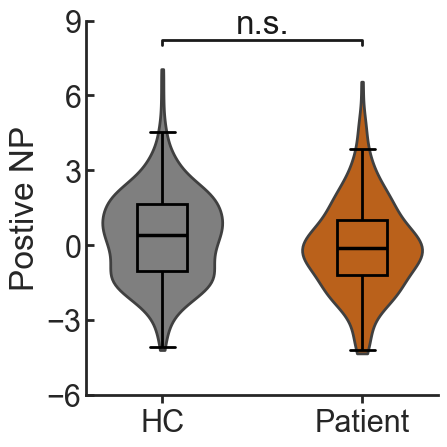

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig1/pos_neg_np_stratify_resi_without_ed.csv')

# 配色
palette = {
    'HC': (127/255, 127/255, 127/255),
    'Patient': (213/255, 94/255, 0/255)
}
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (5, 5)})
sns.set_style("ticks")
# Violin plot + boxplot
ax = sns.violinplot(data=df, x='Group', y='Pos_NP',
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6)
sns.boxplot(
    data=df,
    x='Group',
    y='Pos_NP',
    width=0.25,
    showcaps=True,
    showfliers=False,
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 去除默认坐标轴线右侧和顶部
sns.despine()

ax.tick_params(axis='both', length=6, width=2)
ax.tick_params(axis='y',direction='in')
# 添加显著性星号
group1 = df[df['Group'] == 'HC']['Pos_NP']
group2 = df[df['Group'] == 'Patient']['Pos_NP']

# 比如你想在组1和组2之间画线
x1, x2 = 0, 1      # 两组在x轴上的位置（对应 Group2=1 和 Group2=2）
y = 8              # 横线的位置（y坐标）
h = 0.2            # 横线和星号之间的高度间隔
# 画横线
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
# 添加显著性标注（例如星号）
ax.text((x1+x2)*.5, y+h, "n.s.", ha='center', va='bottom', color='k', fontsize=24)

ax.set_ylim(-6, 9)
ax.set_yticks([-6,-3,0,3,6,9])
plt.ylabel('Postive NP')
plt.xlabel('')
ax.set_xticks([0, 1])
ax.set_xticklabels(['HC', 'Patient'])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/compare_pos_np_without_ed.png', dpi=300, bbox_inches='tight')
plt.show()

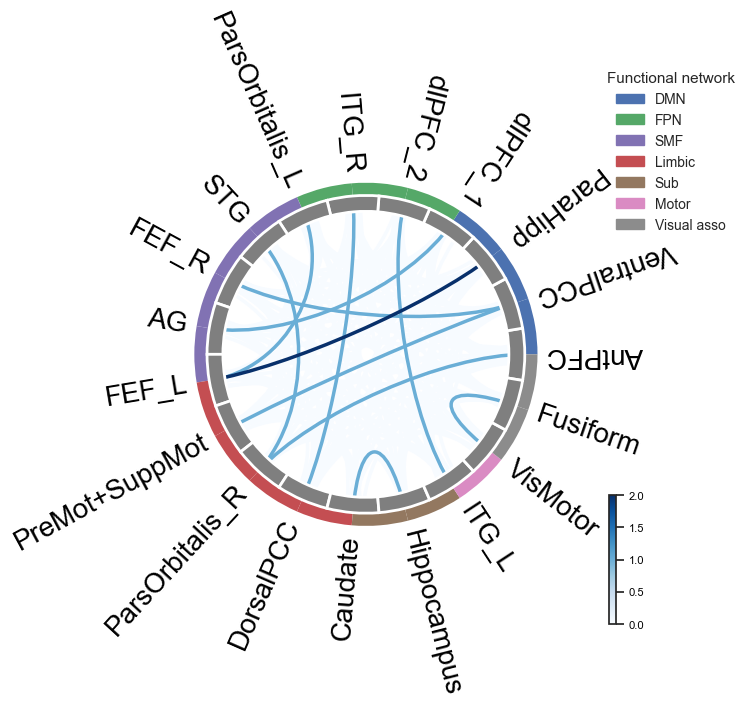

In [366]:
import numpy as np
import matplotlib.pyplot as plt
from mne_connectivity.viz import plot_connectivity_circle
import pandas as pd

df = pd.read_csv(
    '/Users/yunman/Desktop/submission/figures/fig1/np_12_fcs_circos.csv',
    header=None
)
con_matrix = df.values

# 1. 定义 19 个核心脑区名称 (按照解剖逻辑分组)
label_names = [
    'AntPFC','VentralPCC','ParaHipp', #DMN
    'dlPFC_1','dlPFC_2', 'ITG_R',  # fpn
    'ParsOrbitalis_L', 'STG', 'FEF_R',  'AG',            # smf
    'FEF_L', 'PreMot+SuppMot', 'ParsOrbitalis_R','DorsalPCC',  #limbic
    'Caudate', 'Hippocampus',               # sub
    'ITG_L', #motor
    'VisMotor','Fusiform'  #visual association
]

# 2. 模拟 19x19 的连接矩阵 (仅包含你筛选出的 12 条连接)
# 在实际使用时，请替换为你计算出的实测强度

# 因为是对称矩阵，补充另一半
con_matrix = con_matrix + con_matrix.T

# 3. 设置 Nature 风格配色
# 使用我们之前定的深海蓝 (#0072B2) 的渐变
node_colors = ['#7F7F7F'] * 19  # 节点统一用中性灰
edge_cmap = ['#0072B2'] # 连线使用蓝色系

# 4. 绘图
fig, ax = plt.subplots(figsize=(8, 8), facecolor='white', subplot_kw=dict(polar=True))

plot_connectivity_circle(
    con_matrix, 
    label_names, 
    n_lines=12,               # 只显示最重要的 12 条
    node_colors=node_colors,
    colormap='Blues',         # 连线颜色
    facecolor='white',
    textcolor='black',
    node_edgecolor='white',
    linewidth=2.5,              # 线宽
    node_linewidth=2,
    fontsize_names=20,
    padding=5,
    show=False,
    ax=ax,
    colorbar=True
)

# 调整文字位置（手动）
for text in ax.texts:
    text.set_position((text.get_position()[0], text.get_position()[1] + 1))
    
# 5. 外圈功能网络环
# =========================
n_nodes = len(label_names)
angles = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False)
node_radius = 0.08       # 默认 chord circle node radius
outer_radius = 10 # 在节点外面一点
ring_width = 0.8       # 环厚度

for angle, net in zip(angles, networks):
    ax.bar(
        angle,
        ring_width,
        width=2 * np.pi / n_nodes,
        bottom=outer_radius,
        color=net_colors[net],
        edgecolor='none',
        align='edge',
        zorder=0
    )

# =========================
# 6. legend
# =========================
legend_patches = [
    mpatches.Patch(color=net_colors[k], label=k)
    for k in net_colors
]

ax.legend(
    handles=legend_patches,
    title='Functional network',
    loc='upper right',
    bbox_to_anchor=(1.3, 1.12),
    frameon=False,
    prop={'family':'Arial', 'size':10},   # 设置字体族和大小
    title_fontsize=11
)
    
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig1/np_circos_legend_2.png', dpi=300, bbox_inches='tight')
plt.show()

In [73]:
pip install mne-connectivity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 49.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 56.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [mne-connectivity][mne]ay]]
Note: you may need to restart the kernel to use updated packages.


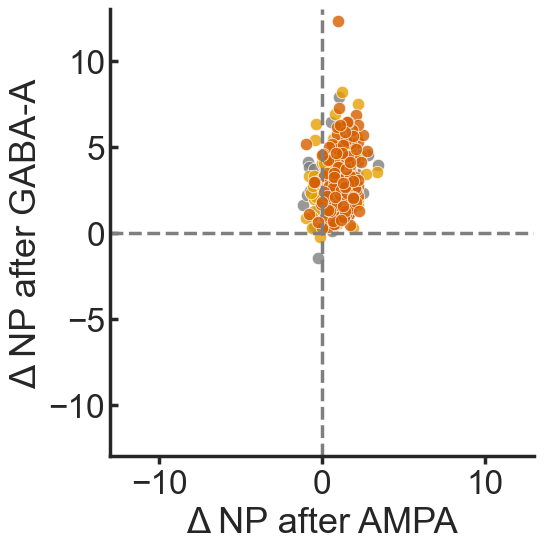

In [408]:
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(
    '/Users/yunman/Desktop/submission/figures/fig3/changes_np_after_modulation.csv'
)
# ===============================
# 1. 基本设置
# ===============================
plt.figure(figsize=(6, 6))

group_order = ['HC', 'High-symptom', 'Patient']
group_colors = {
    'HC': '#7F7F7F',            # grey
    'High-symptom': '#E69F00',  # orange
    'Patient': '#D55E00'        # red
}

# ===============================
# 2. 画散点（每个点 = 个体）
# ===============================
for g in group_order:
    sub = df[df['Group'] == g]
    plt.scatter(
        sub['dAMPA'],
        sub['dGABA'],
        s=80,
        alpha=0.8,
        color=group_colors[g],
        label=g,
        edgecolor='white',
        linewidth=0.6
    )

# ===============================
# 3. 原点 & 四象限参考线
# ===============================

x_lim = (-13, 13)
y_lim = (-13, 13)

plt.xlim(x_lim)
plt.ylim(y_lim)
# （可选）虚线增强四象限感
plt.axhline(0, color='#7F7F7F', linestyle='--', linewidth=2.5)
plt.axvline(0, color='#7F7F7F', linestyle='--', linewidth=2.5)

# ===============================
# 4. 四象限文字标注（Nature 推荐）
# ===============================
#ax = plt.gca()
#ax.text(0.98, 0.98, 'AMPA ↑  |  GABA ↑',
#        transform=ax.transAxes,
#        ha='right', va='top', fontsize=18)

#ax.text(0.02, 0.98, 'AMPA ↓  |  GABA ↑',
#        transform=ax.transAxes,
#        ha='left', va='top', fontsize=18)

#ax.text(0.02, 0.02, 'AMPA ↓  |  GABA ↓',
#        transform=ax.transAxes,
#        ha='left', va='bottom', fontsize=18)

#ax.text(0.98, 0.02, 'AMPA ↑  |  GABA ↓',
#        transform=ax.transAxes,
#        ha='right', va='bottom', fontsize=18)

# ===============================
# 5. 轴标签 & 美化
# ===============================
plt.xlabel('Δ NP after AMPA', fontsize=26)
plt.ylabel('Δ NP after GABA-A', fontsize=26)

ax.set_aspect('equal', adjustable='box')  # 四象限比例一致
sns.despine()


# ===============================
# 6. 导出
# ===============================
plt.tight_layout()
plt.tick_params(axis='both', labelsize=24,width=2.5)
plt.tick_params(axis='y', direction='in')
ax.spines['bottom'].set_linewidth(2.5) #
plt.savefig(
    '/Users/yunman/Desktop/submission/figures/fig3/AMPA_GABA_quadrant.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/224727545.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sub, x='kmeans_win_diff_hd_reverse', y='placebo_win_exclude_hd',
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_62142/224727545.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Increased','Decreased'], rotation=30)


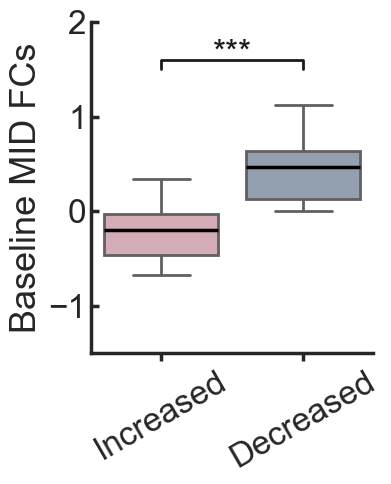

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/pharmacological_exper/NP_fcs_only_win_mean.csv')
df_sub = df[df['kmeans_win_diff_hd_reverse'].isin(['Subgroup1', 'Subgroup2'])]

# 参数
sns.set(style="ticks", rc={'figure.figsize': (4, 5)})
group_order = ['Subgroup1', 'Subgroup2']
color_map = {
    'Subgroup1': '#D9A5B3',
    'Subgroup2': '#8DA0B4'}

# 绘图
fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=df_sub, x='kmeans_win_diff_hd_reverse', y='placebo_win_exclude_hd',
            dodge=False, palette=color_map, order=group_order, ax=ax, linewidth=3, showfliers=False,
           boxprops=dict(linewidth=2),
           whiskerprops=dict(linewidth=2),
           capprops=dict(linewidth=2),
           medianprops=dict(
           linewidth=0,
           color='black',
           zorder=10),
           )

# 计算并画均值线
for i, g in enumerate(group_order):
    mean_val = df[df['kmeans_win_diff_hd_reverse'] == g]['placebo_win_exclude_hd'].mean()
    
    ax.hlines(
        y=mean_val,
        xmin=i - 0.4,
        xmax=i + 0.4,
        colors='black',
        linewidth=2.5,
        zorder=10
    )
sns.despine()
ax.set_xticklabels(['Increased','Decreased'], rotation=30)
ax.set_ylabel('Baseline MID FCs')
ax.set_xlabel('')
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='both', length=6, width=2.5,labelsize=24)
ax.tick_params(axis='y', direction='in')
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
# 添加显著性星号
group1 = df[df['kmeans_win_diff_hd_reverse'] == 'Subgroup1']['placebo_win_exclude_hd']
group2 = df[df['kmeans_win_diff_hd_reverse'] == 'Subgroup2']['placebo_win_exclude_hd']

# 比如你想在组1和组2之间画线
x1, x2 = 0, 1      # 两组在x轴上的位置（对应 Group2=1 和 Group2=2）
y = 1.5             # 横线的位置（y坐标）
h = 0.1            # 横线和星号之间的高度间隔
# 画横线
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
# 添加显著性标注（例如星号）
ax.text((x1+x2)*.5, y+h-0.1, "***", ha='center', va='bottom', color='k', fontsize=24)

# 调整y最大值
plt.ylim(-1.5,2)
ax.set_yticks([-1,0,1,2])
ax.set_ylabel('Baseline MID FCs', fontsize=26)
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig4/compare_placebo_mid.png',
            dpi=300, bbox_inches='tight')
plt.show()


/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/1090203979.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Group', y='Simulated NP_cov_sex_site_hd',order=group_order,
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/1090203979.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(group_order, rotation=20, ha='right')


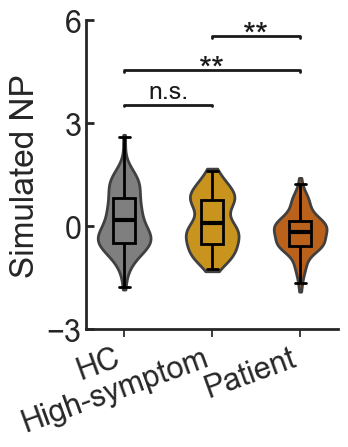

In [459]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/mani_ampa_gaba_subs3.csv')

# 配色
palette = {
    'HC': '#7F7F7F',
    'High-symptom': '#E69F00',
    'Patient': '#D55E00'
}
group_order = ['HC', 'High-symptom', 'Patient']
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (4, 5)})
sns.set_style("ticks")
# Violin plot + boxplot
ax = sns.violinplot(data=df, x='Group', y='Simulated NP_cov_sex_site_hd',order=group_order,
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6)
sns.boxplot(
    data=df,
    x='Group',
    y='Simulated NP_cov_sex_site_hd',
    width=0.25,
    showcaps=True,
    showfliers=False,
    order=group_order, 
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=0),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 计算并画均值线
for i, g in enumerate(group_order):
    mean_val = df[df['Group'] == g]['Simulated NP_cov_sex_site_hd'].mean()
    
    ax.hlines(
        y=mean_val,
        xmin=i - 0.12,
        xmax=i + 0.12,
        colors='black',
        linewidth=3,
        zorder=10
    )
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='y', length=6, width=2, direction='in')
ax.set_xticklabels(group_order, rotation=20, ha='right')
# 绘制横线和显著性标注
# HC vs High-symptom
ax.plot([0, 0, 1, 1], [3.5, 3.55, 3.55, 3.5], lw=2, c='k')  # 横线
ax.text(0.5, 3.6, "n.s.", ha='center', va='bottom', color='k', fontsize=18)

# HC vs Patient
ax.plot([0, 0, 2, 2], [4.5, 4.55, 4.55, 4.5], lw=2, c='k')
ax.text(1, 4.1, "**", ha='center', va='bottom', color='k', fontsize=24)

# High-symptom vs Patient
ax.plot([1, 1, 2, 2], [5.5, 5.55, 5.55, 5.5], lw=2, c='k')
ax.text(1.5, 5.1, "**", ha='center', va='bottom', color='k', fontsize=24)  # 可以单独调整字体

ax.set_ylim(-3, 6)
ax.set_yticks([-3,0,3,6])
plt.ylabel('Simulated NP')
plt.xlabel('')
ax.set_xticks([0,1,2])
ax.set_xticklabels(['HC','High-symptom','Patient'])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/compare_simulated_np.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/2516752198.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Group', y='Manipulated NP_cov_sex_site_hd',order=group_order,
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/2516752198.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(group_order, rotation=20, ha='right')


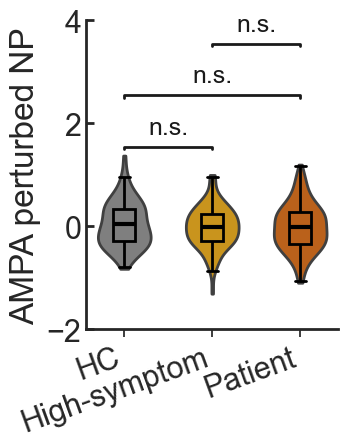

In [461]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/mani_ampa_gaba_subs3.csv')

# 配色
palette = {
    'HC': '#7F7F7F',
    'High-symptom': '#E69F00',
    'Patient': '#D55E00'
}
group_order = ['HC', 'High-symptom', 'Patient']
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (4, 5)})
sns.set_style("ticks")
# Violin plot + boxplot
ax = sns.violinplot(data=df, x='Group', y='Manipulated NP_cov_sex_site_hd',order=group_order,
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6)
sns.boxplot(
    data=df,
    x='Group',
    y='Manipulated NP_cov_sex_site_hd',
    width=0.25,
    showcaps=True,
    showfliers=False,
    order=group_order, 
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=0),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 计算并画均值线
for i, g in enumerate(group_order):
    mean_val = df[df['Group'] == g]['Manipulated NP_cov_sex_site_hd'].mean()
    
    ax.hlines(
        y=mean_val,
        xmin=i - 0.12,
        xmax=i + 0.12,
        colors='black',
        linewidth=3,
        zorder=10
    )
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='y', length=6, width=2, direction='in')
ax.set_xticklabels(group_order, rotation=20, ha='right')

# 绘制横线和显著性标注
# HC vs High-symptom
ax.plot([0, 0, 1, 1], [1.5, 1.55, 1.55, 1.5], lw=2, c='k')  # 横线
ax.text(0.5, 1.7, "n.s.", ha='center', va='bottom', color='k', fontsize=18)

# HC vs Patient
ax.plot([0, 0, 2, 2], [2.5, 2.55, 2.55, 2.5], lw=2, c='k')
ax.text(1, 2.7, "n.s.", ha='center', va='bottom', color='k', fontsize=18)

# High-symptom vs Patient
ax.plot([1, 1, 2, 2], [3.5, 3.55, 3.55, 3.5], lw=2, c='k')
ax.text(1.5, 3.7, "n.s.", ha='center', va='bottom', color='k', fontsize=18)  # 可以单独调整字体
# 调整y最大值
ax.set_ylim(-2, 4)
ax.set_yticks([-2,0,2,4])
plt.ylabel('AMPA perturbed NP')
plt.xlabel('')
ax.set_xticks([0,1,2])
ax.set_xticklabels(['HC','High-symptom','Patient'])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/compare_manipu_ampa_np.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/4025396740.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Group', y='Manipulated_gaba_with_high_ampa_mid_resi',order=group_order,
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/4025396740.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(group_order, rotation=20, ha='right')


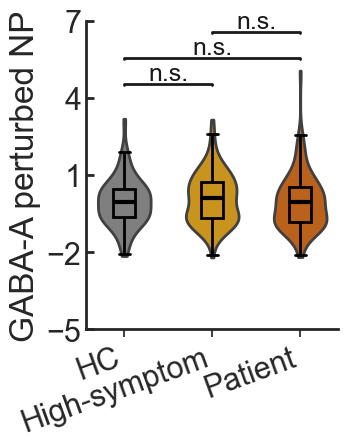

In [464]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/mani_ampa_gaba_subs3.csv')

# 配色
palette = {
    'HC': '#7F7F7F',
    'High-symptom': '#E69F00',
    'Patient': '#D55E00'
}
group_order = ['HC', 'High-symptom', 'Patient']
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (4, 5)})
sns.set_style("ticks")
# Violin plot + boxplot
ax = sns.violinplot(data=df, x='Group', y='Manipulated_gaba_with_high_ampa_mid_resi',order=group_order,
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6)
sns.boxplot(
    data=df,
    x='Group',
    y='Manipulated_gaba_with_high_ampa_mid_resi',
    width=0.25,
    showcaps=True,
    showfliers=False,
    order=group_order, 
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=0),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 计算并画均值线
for i, g in enumerate(group_order):
    mean_val = df[df['Group'] == g]['Manipulated_gaba_with_high_ampa_mid_resi'].mean()
    
    ax.hlines(
        y=mean_val,
        xmin=i - 0.12,
        xmax=i + 0.12,
        colors='black',
        linewidth=3,
        zorder=10
    )
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='y', length=6, width=2, direction='in')
ax.set_xticklabels(group_order, rotation=20, ha='right')


# 绘制横线和显著性标注
# HC vs High-symptom
ax.plot([0, 0, 1, 1], [4.5, 4.55, 4.55, 4.5], lw=2, c='k')  # 横线
ax.text(0.5, 4.5, "n.s.", ha='center', va='bottom', color='k', fontsize=18)

# HC vs Patient
ax.plot([0, 0, 2, 2], [5.5, 5.55, 5.55, 5.5], lw=2, c='k')
ax.text(1, 5.5, "n.s.", ha='center', va='bottom', color='k', fontsize=18)

# High-symptom vs Patient
ax.plot([1, 1, 2, 2], [6.5, 6.55, 6.55, 6.5], lw=2, c='k')
ax.text(1.5, 6.5, "n.s.", ha='center', va='bottom', color='k', fontsize=18)  # 可以单独调整字体
# 调整y最大值
plt.ylim(-5,7)
ax.set_yticks(range(-5, 8, 3))

plt.ylabel('GABA-A perturbed NP')
plt.xlabel('')
ax.set_xticks([0,1,2])
ax.set_xticklabels(['HC','High-symptom','Patient'])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/compare_manipu_gaba_np.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/1209863048.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Group', y='np_factor_2_cov_sex_site_hd',order=group_order,
/var/folders/r1/txswsvt15yj4t92wgwfx1yzm0000gn/T/ipykernel_24219/1209863048.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(group_order, rotation=30, ha='right')


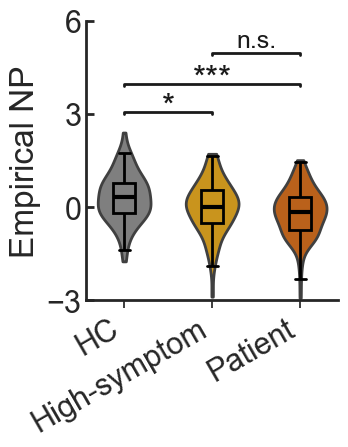

In [410]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
import pandas as pd
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/mani_ampa_gaba_subs3.csv')

# 配色
palette = {
    'HC': '#7F7F7F',
    'High-symptom': '#E69F00',
    'Patient': '#D55E00'
}
group_order = ['HC', 'High-symptom', 'Patient']
sns.set(font_scale=2, style="ticks", rc={'figure.figsize': (4, 5)})
sns.set_style("ticks")
# Violin plot + boxplot
ax = sns.violinplot(data=df, x='Group', y='np_factor_2_cov_sex_site_hd',order=group_order,
               palette=palette, inner=None, linewidth=2, cut=0.2, width=0.6)
sns.boxplot(
    data=df,
    x='Group',
    y='np_factor_2_cov_sex_site_hd',
    width=0.25,
    showcaps=True,
    showfliers=False,
    order=group_order, 
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=2),
    medianprops=dict(color='black', linewidth=0),
    whiskerprops=dict(color='black', linewidth=2),
    capprops=dict(color='black', linewidth=2),
    ax=ax
)
# 计算并画均值线
for i, g in enumerate(group_order):
    mean_val = df[df['Group'] == g]['np_factor_2_cov_sex_site_hd'].mean()
    
    ax.hlines(
        y=mean_val,
        xmin=i - 0.12,
        xmax=i + 0.12,
        colors='black',
        linewidth=3,
        zorder=10
    )
# 去除默认坐标轴线右侧和顶部
sns.despine()
ax.tick_params(axis='y', length=6, width=2, direction='in')
ax.set_xticklabels(group_order, rotation=30, ha='right')
# 绘制横线和显著性标注
# HC vs High-symptom
ax.plot([0, 0, 1, 1], [3, 3.05, 3.05, 3], lw=2, c='k')  # 横线
ax.text(0.5, 2.7, "*", ha='center', va='bottom', color='k', fontsize=24)

# HC vs Patient
ax.plot([0, 0, 2, 2], [3.9, 3.95, 3.95, 3.9], lw=2, c='k')
ax.text(1, 3.6, "***", ha='center', va='bottom', color='k', fontsize=24)

# High-symptom vs Patient
ax.plot([1, 1, 2, 2], [4.9, 4.95, 4.95, 4.9], lw=2, c='k')
ax.text(1.5, 5.0, "n.s.", ha='center', va='bottom', color='k', fontsize=18)  # 可以单独调整字体

ax.set_ylim(-3, 6)
ax.set_yticks([-3,0,3,6])
plt.ylabel('Empirical NP')
plt.xlabel('')
ax.set_xticks([0,1,2])
ax.set_xticklabels(['HC','High-symptom','Patient'])
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig3/compare_empirical_np.png', dpi=300, bbox_inches='tight')
plt.show()

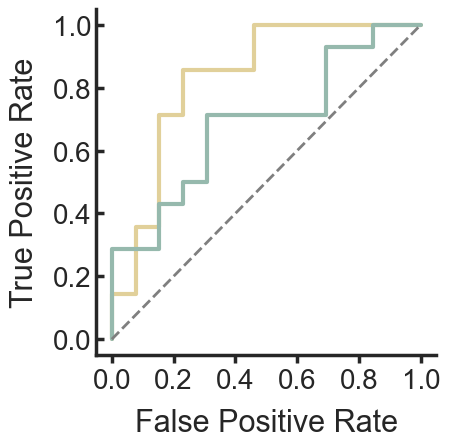

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 模拟数据 (请替换为你的真实预测值 y_score 和 真实标签 y_true)
# 这里为了演示，生成了两个不同性能的模拟结果
df = pd.read_csv('/Users/yunman/Desktop/submission/figures/fig4/predict_drug_response_use_placebo_mid/auc_curve.csv')
fpr1 = df.midazolam_x
tpr1 = df.midazolam_y

# 模型 2 (AUC = 0.70)
fpr2 = df.ketamine_x
tpr2 = df.ketamine_y

real_auc1 = auc(fpr1, tpr1)
real_auc2 = auc(fpr2, tpr2)
# 3. 开始绘图
plt.figure(figsize=(5, 5))

# 使用你之前的配色方案：绿色和蓝色
plt.plot(fpr1, tpr1, color='#E1D09A', lw=3, 
         label=f'GABA-A-derived model (AUC = {real_auc1:.2f})')
plt.plot(fpr2, tpr2, color='#96B9AD', lw=3, 
         label=f'AMPA-derived model (AUC = {real_auc2:.2f})')

# 画随机猜测线 (对角线)
plt.plot([0, 1], [0, 1], color='#7F7F7F', lw=2, linestyle='--')

# 4. 视觉优化
ax = plt.gca()
# 设置坐标轴粗细
ax.spines['bottom'].set_linewidth(2.5)
ax.spines['left'].set_linewidth(2.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置刻度
plt.tick_params(axis='both', width=2.5, labelsize=20)
plt.xticks(np.arange(0, 1.1, 0.2))
plt.yticks(np.arange(0, 1.1, 0.2))

# 标签与标题
plt.xlabel('False Positive Rate', fontsize=22,labelpad=10)
plt.ylabel('True Positive Rate', fontsize=22,labelpad=10)
ax.tick_params(axis='both', width=2.5, labelsize=20)
ax.tick_params(axis='y', direction='in',length=6)
plt.title('')

# 图例位置（通常放在右下角最安全）
#plt.legend(loc="lower right", frameon=False, fontsize=12)

#plt.grid(alpha=0.2, linestyle=':') # 添加淡淡的网格线方便读数

plt.tight_layout()
plt.savefig('/Users/yunman/Desktop/submission/figures/fig4/auc_curve.png', dpi=300, bbox_inches='tight')
plt.show()